### 1. colab 연동

In [2]:
from google.colab import drive
drive.mount('/content/drive')
!cp /content/drive/MyDrive/cifar100/cifar100.zip /content/
!unzip -q /content/cifar100.zip -d /content/dataset/

Mounted at /content/drive


In [3]:
from sklearn.model_selection import train_test_split
from torchsummary import summary
from tqdm import tqdm
import torch.optim.lr_scheduler as lr_scheduler

### 2. CIFAR100 data로 train, test dataset,loader 만들기

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_dir = 'dataset/cifar100/train'
test_dir = 'dataset/cifar100/test'

transform = transforms.Compose([
    # transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ]
)

train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

train_loader_128 = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader_128 = DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f'Number of training samples: {len(train_dataset)}')
print(f'Number of testing samples: {len(test_dataset)}')
print(f'Number of classes: {len(train_dataset.classes)}')
print(f'Class names: {train_dataset.classes}')
print(f'Example image shape: {train_dataset[0][0].shape}')

Number of training samples: 50000
Number of testing samples: 10000
Number of classes: 100
Class names: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'te

### 3. 모델 정의


In [13]:
import torch.nn as nn

class depthwise_separable_conv(nn.Module):
    def __init__(self,in_channels,out_channels,stride, activation=nn.ReLU, norm_layer=nn.BatchNorm2d, layer_suffle=False):
        super(depthwise_separable_conv,self).__init__()
        if layer_suffle:
            self.dconv = nn.Sequential(
                nn.Conv2d(in_channels,in_channels,3,stride,1,groups=1),
                activation(),
                norm_layer(in_channels)
            )
            self.conv = nn.Sequential(
                nn.Conv2d(in_channels,out_channels,1,1),
                activation(),
                norm_layer(out_channels)
            )
        else:
            self.dconv = nn.Sequential(
                nn.Conv2d(in_channels,in_channels,3,stride,1,groups=in_channels),
                norm_layer(in_channels),
                activation()
            )
            self.conv = nn.Sequential(
                nn.Conv2d(in_channels,out_channels,1,1),
                norm_layer(out_channels),
                activation()
            )

    def forward(self,x):
        out = self.dconv(x)
        out = self.conv(out)

        return out


class MobileNet(nn.Module):
    def __init__(self,a=1, activation=nn.ReLU, norm_layer=nn.BatchNorm2d, layer_suffle=False, num_layers=8):
        super(MobileNet,self).__init__()
        
        self.conv1 = nn.Sequential(
            nn.Conv2d(3,32*a,3,2,1),
            norm_layer(32*a),
            activation()
        )

        self.Mobile = nn.Sequential(
            depthwise_separable_conv(32*a,64,1, activation, norm_layer, layer_suffle),
            depthwise_separable_conv(64,128,2, activation, norm_layer, layer_suffle),
            depthwise_separable_conv(128,128,1, activation, norm_layer, layer_suffle),
            depthwise_separable_conv(128,256,2, activation, norm_layer, layer_suffle),
            depthwise_separable_conv(256,256,1, activation, norm_layer, layer_suffle),
            depthwise_separable_conv(256,512,2, activation, norm_layer, layer_suffle),
            depthwise_separable_conv(512,1024,1, activation, norm_layer, layer_suffle),
            nn.AdaptiveAvgPool2d(1)
        )

        self.Mobile = nn.Sequential(*self.Mobile[:(-1-(8-num_layers))], self.Mobile[-1])
        self.final_channels = [32, 64, 128, 128, 256, 256, 512, 1024]

        self.dropout = nn.Dropout(0.5)

        self.FC = nn.Sequential(
            nn.Linear(self.final_channels[num_layers-1],100)
        )

    def forward(self,x):
        out = self.conv1(x)
        out = self.Mobile(out)
        out = out.view(out.size(0),-1)
        out = self.dropout(out)
        out = self.FC(out)

        return out

In [14]:
summary(MobileNet().to(device), (3,32,32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 16, 16]             896
       BatchNorm2d-2           [-1, 32, 16, 16]              64
              ReLU-3           [-1, 32, 16, 16]               0
            Conv2d-4           [-1, 32, 16, 16]             320
       BatchNorm2d-5           [-1, 32, 16, 16]              64
              ReLU-6           [-1, 32, 16, 16]               0
            Conv2d-7           [-1, 64, 16, 16]           2,112
       BatchNorm2d-8           [-1, 64, 16, 16]             128
              ReLU-9           [-1, 64, 16, 16]               0
depthwise_separable_conv-10           [-1, 64, 16, 16]               0
           Conv2d-11             [-1, 64, 8, 8]             640
      BatchNorm2d-12             [-1, 64, 8, 8]             128
             ReLU-13             [-1, 64, 8, 8]               0
           Conv2d-14            

### 4. train, test 함수 정의

In [15]:
def train(dataloader , model , loss_fn , optimizer , lr_scheduler):
    size = 0
    num_batches = len(dataloader)
    scaler = torch.amp.GradScaler(cuda=device.type=='cuda')

    model.train()
    epoch_loss , epoch_correct = 0 , 0

    for i ,(data_ , target_) in enumerate(dataloader):
        data_ , target_ = data_.to(device), target_.to(device)
        optimizer.zero_grad()

        output_ = model(data_)

        loss = loss_fn(output_, target_)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        pred = output_.argmax(dim=1)
        correct = (pred == target_).sum().item()
        epoch_correct += correct
        epoch_loss += loss.item()
        size += len(data_)

    train_acc = epoch_correct/size
    lr_scheduler.step()

    return train_acc , epoch_loss / num_batches

In [16]:
def test(dataloader , model , loss_fn):
    size = 0
    num_baches = len(dataloader)
    epoch_loss , epoch_correct= 0 ,0
    with torch.no_grad(): # grad 연산 X
        model.eval() # evaluation dropout 연산시
        for i, (data_ , target_) in enumerate(dataloader):

            data_ , target_ = data_.to(device), target_.to(device)
            output_ = model(data_)
            loss = loss_fn(output_, target_)

            pred = output_.argmax(dim=1)
            correct = (pred == target_).sum().item()
            epoch_correct += correct
            epoch_loss += loss.item()
            size += len(data_)

    test_acc = epoch_correct/size

    return test_acc  , epoch_loss / num_baches

### 5. 학습 및 테스트

In [17]:
EPOCHS = 15

suffle_train_logs = {"Conv_Norm_ReLU_acc":[],
                    "Conv_ReLU_Norm_acc":[],
                    "Conv_LeakyReLU_Norm_acc":[]
                    }
suffle_test_logs = {"Conv_Norm_ReLU_acc":[],
                    "Conv_ReLU_Norm_acc":[],
                    "Conv_LeakyReLU_Norm_acc":[]
                    }

models = {
    "Conv_Norm_ReLU": MobileNet(activation=nn.ReLU).to(device),
    "Conv_ReLU_Norm": MobileNet(layer_suffle=True).to(device),
    "Conv_LeakyReLU_Norm": MobileNet(activation=nn.LeakyReLU, layer_suffle=True).to(device)
}
models_name = list(models.keys())
criterion = nn.CrossEntropyLoss()

In [ ]:
# activation별 모델 학습
suffle_test_logs_name = list(suffle_test_logs.keys())
iteration = 0
for iteration in range(len(models)):
    current_model = models[models_name[iteration]]
    optimizer = optim.SGD(current_model.parameters(), 1e-3, momentum=0.9, nesterov=True, weight_decay=5e-4)
    scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    print('='*50)
    print(f'current_model: {models_name[iteration]}')
    print('='*50)
    for epoch in tqdm(range(EPOCHS)):
        train_acc, train_loss = train(train_loader_128, current_model, criterion, optimizer, scheduler)
        test_acc, test_loss = test(test_loader_128, current_model, criterion)

        print(f'train_acc:{train_acc:.4f} test_acc:{test_acc:.4f}\n')

        suffle_train_logs[suffle_test_logs_name[iteration]].append(train_acc)
        suffle_test_logs[suffle_test_logs_name[iteration]].append(test_acc)

current_model: Conv_Norm_ReLU


  7%|▋         | 1/15 [00:22<05:08, 22.01s/it]


train_acc:0.0745 test_acc:0.1409


 13%|█▎        | 2/15 [00:43<04:45, 21.93s/it]


train_acc:0.1753 test_acc:0.2142


...


train_acc:0.7157 test_acc:0.3457


 93%|█████████▎| 14/15 [05:11<00:22, 22.25s/it]


train_acc:0.7460 test_acc:0.3465


100%|██████████| 15/15 [05:33<00:00, 22.24s/it]


train_acc:0.7618 test_acc:0.3465


### 7. 시각화

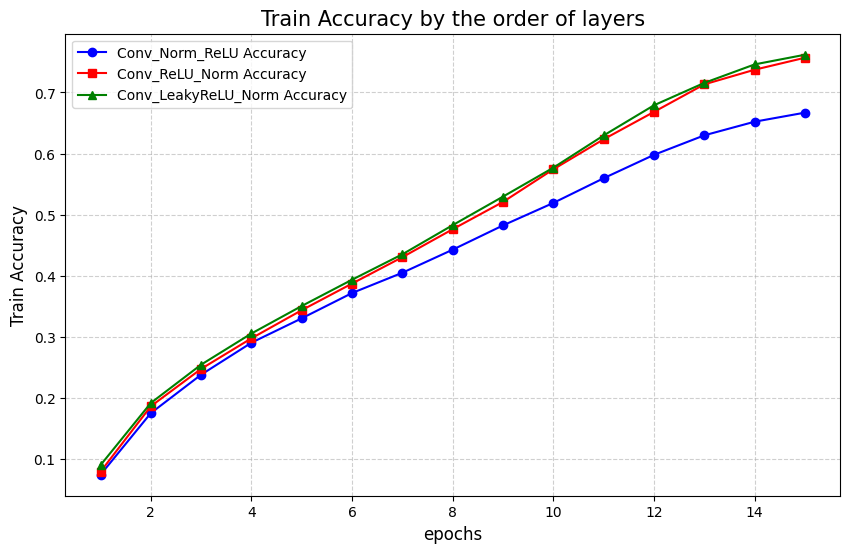

In [19]:
import matplotlib.pyplot as plt

# suffle별 Train 정확도 시각화
plt.figure(figsize=(10, 6))
epochs = range(1, EPOCHS + 1)

plt.plot(epochs, suffle_train_logs["Conv_Norm_ReLU_acc"], 'b-o', label='Conv_Norm_ReLU Accuracy')
plt.plot(epochs, suffle_train_logs["Conv_ReLU_Norm_acc"], 'r-s', label='Conv_ReLU_Norm Accuracy')
plt.plot(epochs, suffle_train_logs["Conv_LeakyReLU_Norm_acc"], 'g-^', label='Conv_LeakyReLU_Norm Accuracy')

plt.title(f'Train Accuracy by the order of layers', fontsize=15)
plt.xlabel('epochs', fontsize=12)
plt.ylabel('Train Accuracy', fontsize=12)
plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

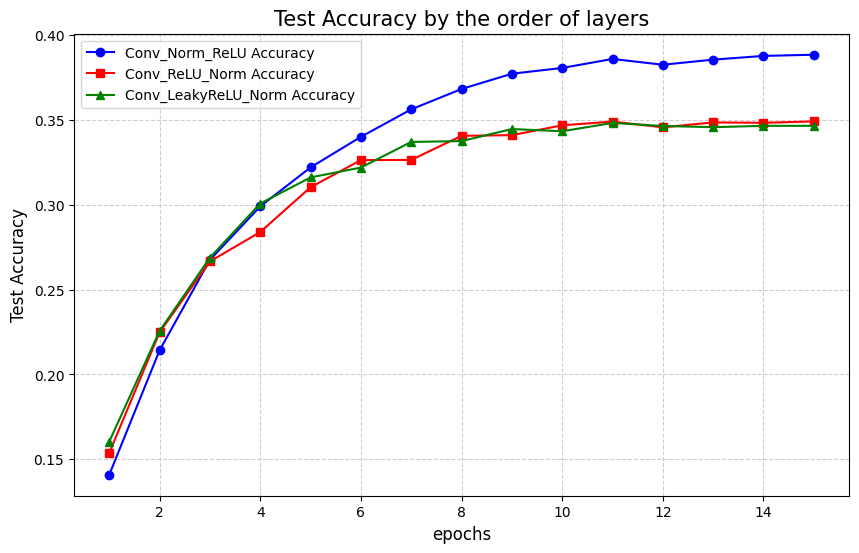

In [20]:
import matplotlib.pyplot as plt

# suffle별 Test 정확도 시각화
plt.figure(figsize=(10, 6))
epochs = range(1, EPOCHS + 1)

plt.plot(epochs, suffle_test_logs["Conv_Norm_ReLU_acc"], 'b-o', label='Conv_Norm_ReLU Accuracy')
plt.plot(epochs, suffle_test_logs["Conv_ReLU_Norm_acc"], 'r-s', label='Conv_ReLU_Norm Accuracy')
plt.plot(epochs, suffle_test_logs["Conv_LeakyReLU_Norm_acc"], 'g-^', label='Conv_LeakyReLU_Norm Accuracy')

plt.title(f'Test Accuracy by the order of layers', fontsize=15)
plt.xlabel('epochs', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

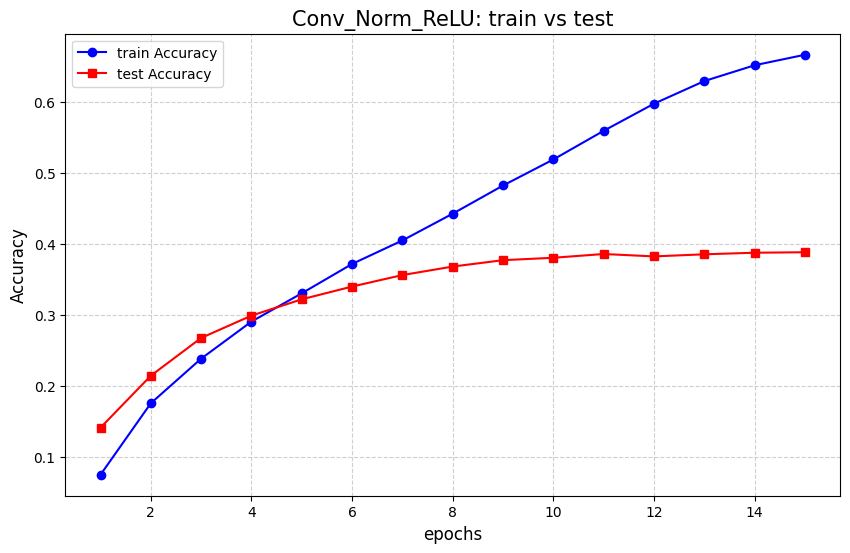

In [21]:
import matplotlib.pyplot as plt

# epoch당 모델별 정확도 시각화
plt.figure(figsize=(10, 6))
epochs = range(1, EPOCHS + 1)

plt.plot(epochs, suffle_train_logs["Conv_Norm_ReLU_acc"], 'b-o', label='train Accuracy')
plt.plot(epochs, suffle_test_logs["Conv_Norm_ReLU_acc"], 'r-s', label='test Accuracy')

plt.title(f'Conv_Norm_ReLU: train vs test', fontsize=15)
plt.xlabel('epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

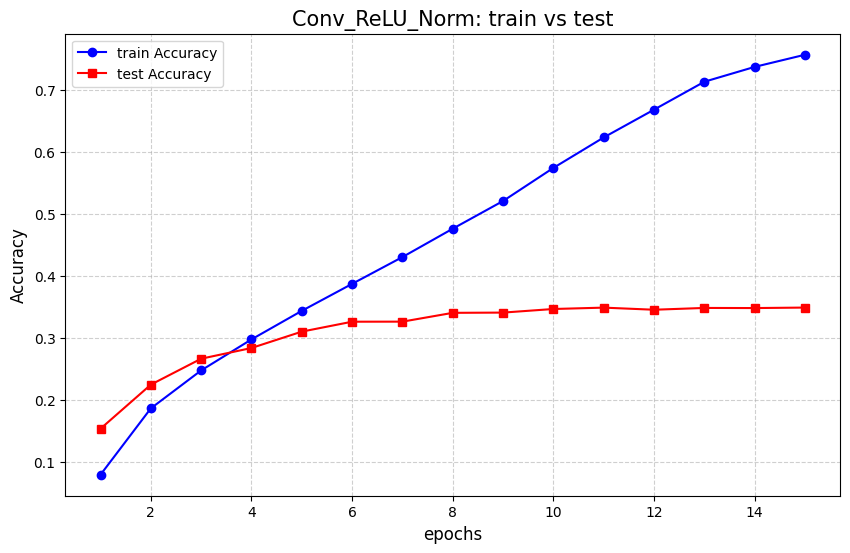

In [22]:
import matplotlib.pyplot as plt

# epoch당 모델별 정확도 시각화
plt.figure(figsize=(10, 6))
epochs = range(1, EPOCHS + 1)

plt.plot(epochs, suffle_train_logs["Conv_ReLU_Norm_acc"], 'b-o', label='train Accuracy')
plt.plot(epochs, suffle_test_logs["Conv_ReLU_Norm_acc"], 'r-s', label='test Accuracy')

plt.title(f'Conv_ReLU_Norm: train vs test', fontsize=15)
plt.xlabel('epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

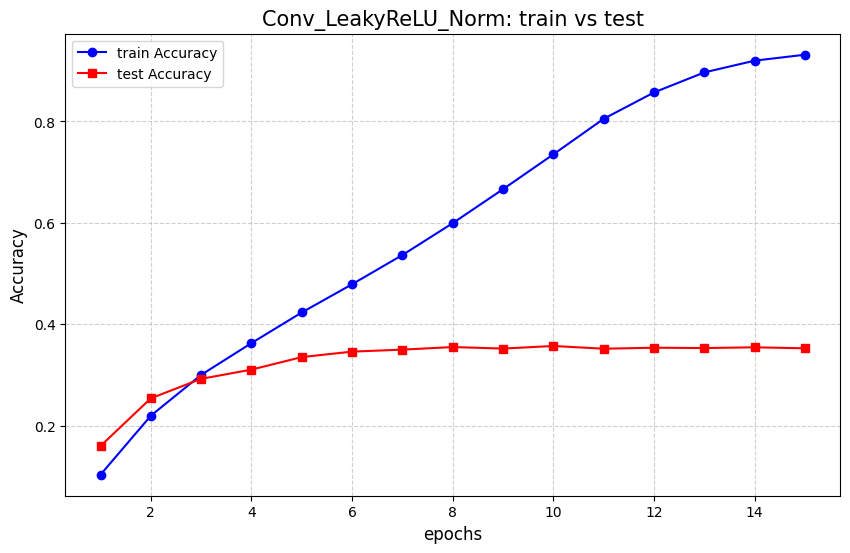

In [18]:
import matplotlib.pyplot as plt

# epoch당 모델별 정확도 시각화
plt.figure(figsize=(10, 6))
epochs = range(1, EPOCHS + 1)

plt.plot(epochs, suffle_train_logs["Conv_LeakyReLU_Norm_acc"], 'b-o', label='train Accuracy')
plt.plot(epochs, suffle_test_logs["Conv_LeakyReLU_Norm_acc"], 'r-s', label='test Accuracy')

plt.title(f'Conv_LeakyReLU_Norm: train vs test', fontsize=15)
plt.xlabel('epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()